In [6]:
import yt
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from matplotlib import gridspec
import numpy as np
import caesar
import pandas as pd
import csv
from astropy.io import fits
from astropy.utils.data import get_pkg_data_filename
from astropy.convolution import Gaussian2DKernel, interpolate_replace_nans
from astropy.convolution import convolve, convolve_fft
from astropy.cosmology import FlatLambdaCDM
import astropy.units as u
import h5py
import math
import eagleSqlTools as sql

In [ ]:
def determining_frb_size(box_size, z, comov, angular_res):
    '''
    Tells you how many pixels you want in your image for a given angular resolution

    :param box_size: Size of the box in units of Mpccm/h 
    :type box_size: float
    :param z: redshift of your snapshot
    :type z: float
    :param comov: Comoving distance in kpc. Suggested to use Ned Wright's cosmology calculator to determine
    :type comov: float
    :param angular_res: The angular size of each pixel you want in your frb in units of arcseconds
    :type angular_res: float
    :return: How many pixels you want to make your frb to achieve the desired angular resolution
    :rtype: int
    '''

    physical_size = box_size/(1+z)/0.68 #Assuming h = 0.68
    #convert resolution to radians and multiply by comoving distance/(1+z) to get physical size of pixel
    pixel = comov*angular_res*(4.84814*10**(-6))/(1+z) 
    frb = physical_size*1000/pixel

    return math.ceil(frb)

In [26]:
galsa='/Volumes/easystore/2025_Pleiades_Runs/z_01/m50n512_1_05_025.hdf5'
gals=caesar.load(galsa)
r=[i.halo.virial_quantities['r200c'] for i in gals.galaxies]

yt : [INFO     ] 2026-04-13 12:07:54,414 Opening /Volumes/easystore/2025_Pleiades_Runs/z_01/m50n512_1_05_025.hdf5
yt : [INFO     ] 2026-04-13 12:07:54,421 Found 131050 halos
yt : [INFO     ] 2026-04-13 12:07:54,425 Found 11210 galaxies


## SIMBA/RAFIKI Simulations

In [16]:
def make_gal_hdf5(galsa, save_toa, z):
    #gals = caesar.load('/Volumes/easystore/2025_Pleiades_Runs/'+galsa)
    gals=caesar.load(galsa)
    save_to = '/Volumes/easystore/RAFIKI_CGM_mock_library/'+save_toa
    #Get galaxy data
    galaxy_stellar = [float(i.masses['stellar'].d) for i in gals.galaxies]
    halodm = [float(i.halo.masses['dm'].d) for i in gals.galaxies]
    halo = [float(i.halo.virial_quantities['m200c'].d) for i in gals.galaxies]
    rad = [float(i.halo.virial_quantities['r200c'].d) for i in gals.galaxies]
    halo5 = [float(i.halo.virial_quantities['m500c'].d) for i in gals.galaxies]
    rad5= [float(i.halo.virial_quantities['r500c'].d) for i in gals.galaxies]
    ages = [float(i.ages['mass_weighted'].d) for  i in gals.galaxies]
    sfr = [float(i.sfr.d )for  i in gals.galaxies]
    galaxies_pos = [i.pos for i in gals.galaxies]
    galaxy_central_flag = [i.central for i in gals.galaxies]

    xp = np.array([pos[0].value/(1+z) for pos in galaxies_pos])
    yp = np.array([pos[1].value/(1+z)  for pos in galaxies_pos])
    zp = np.array([pos[2].value/(1+z)  for pos in galaxies_pos])

    xs=[]
    ys=[]
    zs=[]

    #angular size of pixels in your map in units of arcseconds
    theta = 3 
    #Calculate comoving distance in kpc-use basic cosmology
    cosmo = FlatLambdaCDM(H0=70, Om0=0.3)
    comov = cosmo.comoving_distance(z).to(u.kpc).value 
    frb=determining_frb_size(50, z, comov, theta) #Number of pixels in your fixed resolution buffer, suggested to correspond to resolution at least twice that of your observational comparison
    kpc_size = 50*1000/0.68 #this is still comoving
    conversion_factor= kpc_size/frb
    '''Change the conversion scales from Caesar output to sz data'''
    for i in range(len(galaxies_pos)):
        xs.append(((galaxies_pos[i][0].value)/conversion_factor).item()) 
        ys.append(((galaxies_pos[i][1].value)/conversion_factor).item())
        zs.append(((galaxies_pos[i][2].value)/conversion_factor).item())


    with h5py.File(save_to, 'w') as f:
        meta = f.create_group('metadata')
        meta.attrs['simulation'] = 'SIMBA'
        meta.attrs['redshift']  = z

        props = f.create_group('galaxy_properties')
        props.create_dataset('stellar_mass', data=galaxy_stellar)
        props['stellar_mass'].attrs['units'] = 'Msun'

        props.create_dataset('dm_mass', data=halodm)
        props['dm_mass'].attrs['units'] = 'Msun'

        props.create_dataset('m200c', data=halo)
        props['m200c'].attrs['units'] = 'Msun'

        props.create_dataset('r200c', data=rad)
        props['r200c'].attrs['units'] = 'kpc'

        props.create_dataset('m500c', data=halo5)
        props['m500c'].attrs['units'] = 'Msun'

        props.create_dataset('r500c', data=rad5)
        props['r500c'].attrs['units'] = 'kpc'

        props.create_dataset('age', data=ages)
        props['age'].attrs['units'] = 'Gyr'

        props.create_dataset('sfr', data=sfr)
        props['sfr'].attrs['units'] = 'Msun/yr'

        props.create_dataset('central', data = galaxy_central_flag)
        props['central'].attrs['units'] = ''

        plocs = f.create_group('physical_locations')
        plocs.create_dataset('x', data=xp)
        plocs.create_dataset('y', data=yp)
        plocs.create_dataset('z', data=zp)
        plocs.attrs['units']       = 'kpc'
        plocs.attrs['description'] = 'Galaxy positions in physical kpc'

        locs = f.create_group('frb_locations')
        locs.create_dataset('x', data=xs)
        locs.create_dataset('y', data=ys)
        locs.create_dataset('z', data=zs)
        locs.attrs['units']       = 'pixels'
        locs.attrs['description'] = 'Galaxy positions in FRB pixel coordinates'


In [20]:
make_gal_hdf5('/Volumes/easystore/allphys/m50n512_078.hdf5', 'SIMBA/snap_z2/galaxy_catalog.hdf5', 2)

yt : [INFO     ] 2026-04-01 13:59:02,774 Opening /Volumes/easystore/allphys/m50n512_078.hdf5
yt : [INFO     ] 2026-04-01 13:59:03,008 Found 67682 halos
yt : [INFO     ] 2026-04-01 13:59:03,222 Found 3814 galaxies


In [ ]:
#Generate catalogs for all RAFIKI z=2 snapshots
z =0.1

sample_pairs = [['z_0_1/m50n512_1_0125_005.hdf5','RAFIKI_A/snap_z2/galaxy_catalog.hdf5'],['z_2/m50n512_1_025_005.hdf5','RAFIKI_B/snap_z2/galaxy_catalog.hdf5'],['z_2/m50n512_1_05_005.hdf5','RAFIKI_C/snap_z2/galaxy_catalog.hdf5'],
 ['z_2/m50n512_2_0125_005.hdf5','RAFIKI_D/snap_z2/galaxy_catalog.hdf5'],['z_2/m50n512_2_025_005.hdf5','RAFIKI_E/snap_z2/galaxy_catalog.hdf5'],['z_2/m50n512_2_05_005.hdf5','RAFIKI_F/snap_z2/galaxy_catalog.hdf5'],
 ['z_2/m50n512_3_0125_005.hdf5','RAFIKI_G/snap_z2/galaxy_catalog.hdf5'],['z_2/m50n512_3_025_005.hdf5','RAFIKI_H/snap_z2/galaxy_catalog.hdf5'],['z_2/m50n512_3_05_005.hdf5','RAFIKI_I/snap_z2/galaxy_catalog.hdf5']]

for i in sample_pairs:
    make_gal_hdf5(i[0],i[1],z)

## EAGLE

In [8]:

# Load the SZ map
eagle = np.load('/Volumes/easystore/RAFIKI_CGM_mock_library/EAGLE/snap_z1/tSZ/EAGLE_1_x_szy.npy')  # Ensure correct SZ map
box_size=50
# Determine pixel conversion factor
print(eagle.shape[0])
pixel_conversion = eagle.shape[0] / box_size
print(pixel_conversion)
# Optional: Filter galaxies by stellar mass (Uncomment to use)
# if galaxy_stellar is not None:
#     index_sample_a = np.where(galaxy_stellar > 1e11)  # Select galaxies above 1e11 M_sun
#     xpos = xpos[index_sample_a]
#     ypos = ypos[index_sample_a]
#     zpos = zpos[index_sample_a]

# Adjust positions and convert to pixel coordinates
'''xpos_centered = xpos - (box_size / 1000)
ypos_centered = ypos - (box_size / 1000)
zpos_centered = zpos - (box_size / 1000)

xpos_pixels = xpos_centered * pixel_conversion
ypos_pixels = ypos_centered * pixel_conversion
zpos_pixels = zpos_centered * pixel_conversion

return eagle, xpos_pixels, ypos_pixels, zpos_pixels'''

1531
30.62


'xpos_centered = xpos - (box_size / 1000)\nypos_centered = ypos - (box_size / 1000)\nzpos_centered = zpos - (box_size / 1000)\n\nxpos_pixels = xpos_centered * pixel_conversion\nypos_pixels = ypos_centered * pixel_conversion\nzpos_pixels = zpos_centered * pixel_conversion\n\nreturn eagle, xpos_pixels, ypos_pixels, zpos_pixels'

In [9]:
theta = 3 
z=1   
#Calculate comoving distance in kpc-use basic cosmology
cosmo = FlatLambdaCDM(H0=70, Om0=0.3)
comov = cosmo.comoving_distance(z).to(u.kpc).value 
frb=determining_frb_size(50, z, comov, theta) #Number of pixels in your fixed resolution buffer, suggested to correspond to resolution at least twice that of your observational comparison
kpc_size = 50*1000/0.68 #this is still comoving
conversion_factor= kpc_size/frb
print(frb)
print(conversion_factor)

1531
48.02704883390325


In [10]:
def make_gal_hdf5_eagle(sim_name, snapshot,save_to,z):
    save_to = '/Volumes/easystore/RAFIKI_CGM_mock_library/'+save_to
    con = sql.connect("hhb195", password= "YCV99tfw")
    # SQL query to extract relevant galaxy properties
    query = f"""
    SELECT 
        SH.MassType_Star AS stellar_mass,
        FOF.GroupMass as halo_mass,
        SH.InitialMassWeightedStellarAge AS mass_weighted_age,
        SH.StarFormationRate AS sfr,
        SH.CentreOfPotential_X AS xpos,
        SH.CentreOfPotential_Y AS ypos,
        SH.CentreOfPotential_Z AS zpos,
        FOF.Group_M_Crit200 as m200,
        FOF.Group_R_Crit200 as r200,
        FOF.Group_M_Crit500 as m500,
        FOF.Group_R_Crit500 as r500,
        SH.GalaxyID AS id,
        SH.SubGroupNumber as group_number
    FROM 
        {sim_name}_SubHalo AS SH,
        {sim_name}_FOF as FOF
    WHERE 
        SH.SnapNum = {snapshot} AND
        SH.MassType_Star > 1e8 AND
        FOF.SnapNum = SH.SnapNum AND  
        FOF.GroupID = SH.GroupID
    """


   

    # Execute 
    data = sql.execute_query(con, query)

    galaxy_ids = np.array(data['id'])
    galaxy_stellar = np.array(data['stellar_mass'])  
    halo = np.array(data['halo_mass'])    
    ages = np.array(data['mass_weighted_age'])  
    sfr = np.array(data['sfr'])  
    m200= np.array(data['m200'])
    r200=np.array (data['r200'])
    m500= np.array(data['m500'])
    r500=np.array (data['r500'])
    centrals = np.array(data['group_number'])
    # Extract positions and apply necessary scaling if needed
    xpos = np.array(data['xpos'])
    ypos = np.array(data['ypos'])
    zpos = np.array(data['zpos'])

    #angular size of pixels in your map in units of arcseconds
    theta = 3 
    #Calculate comoving distance in kpc-use basic cosmology
    cosmo = FlatLambdaCDM(H0=70, Om0=0.3)
    comov = cosmo.comoving_distance(z).to(u.kpc).value 
    frb=determining_frb_size(50, z, comov, theta) #Number of pixels in your fixed resolution buffer, suggested to correspond to resolution at least twice that of your observational comparison
    box_size=50
    pixel_conversion = frb/box_size

    xpos_centered = xpos - (box_size / 1000)
    ypos_centered = ypos - (box_size / 1000)
    zpos_centered = zpos - (box_size / 1000)

    xs = xpos_centered * pixel_conversion
    ys = ypos_centered * pixel_conversion
    zs = zpos_centered * pixel_conversion




    with h5py.File(save_to, 'w') as f:
        meta = f.create_group('metadata')
        meta.attrs['simulation'] = 'SIMBA'
        meta.attrs['redshift']  = z

        props = f.create_group('galaxy_properties')
        props.create_dataset('ids', data=galaxy_ids)
        props['ids'].attrs['units'] = ''

        props.create_dataset('stellar_mass', data=galaxy_stellar)
        props['stellar_mass'].attrs['units'] = 'Msun'

        props.create_dataset('dm_mass', data=halo)
        props['dm_mass'].attrs['units'] = 'Msun'

        props.create_dataset('m200c', data=halo)
        props['m200c'].attrs['units'] = 'Msun'

        props.create_dataset('r200c', data=r200)
        props['r200c'].attrs['units'] = 'kpc'

        props.create_dataset('m500c', data=m500)
        props['m500c'].attrs['units'] = 'Msun'

        props.create_dataset('r500c', data=r500)
        props['r500c'].attrs['units'] = 'kpc'

        props.create_dataset('age', data=ages)
        props['age'].attrs['units'] = 'Gyr'

        props.create_dataset('sfr', data=sfr)
        props['sfr'].attrs['units'] = 'Msun/yr'

        props.create_dataset('central', data = centrals)
        props['central'].attrs['units'] = ''

        plocs = f.create_group('physical_locations')
        plocs.create_dataset('x', data=xpos)
        plocs.create_dataset('y', data=ypos)
        plocs.create_dataset('z', data=zpos)
        plocs.attrs['units']       = 'kpc'
        plocs.attrs['description'] = 'Galaxy positions in physical kpc'

        locs = f.create_group('frb_locations')
        locs.create_dataset('x', data=xs)
        locs.create_dataset('y', data=ys)
        locs.create_dataset('z', data=zs)
        locs.attrs['units']       = 'pixels'
        locs.attrs['description'] = 'Galaxy positions in FRB pixel coordinates'

        plt.imshow(eagle, norm=colors.LogNorm(vmin=eagle.min(), vmax=eagle.max()), origin='lower')
        plt.title('Fiducial', fontname="Arial", fontsize=20)
        plt.xlim(0,frb)
        plt.xlabel("Y Position [pixels]", fontname="Arial", fontsize=15)
        plt.ylabel("Z Position [pixels]", fontname="Arial", fontsize=15)
        plt.ylim(0,frb)
        plt.scatter(ys, zs, color='red', s=0.1)
        plt.colorbar(label="SZ Signal")
        plt.show()


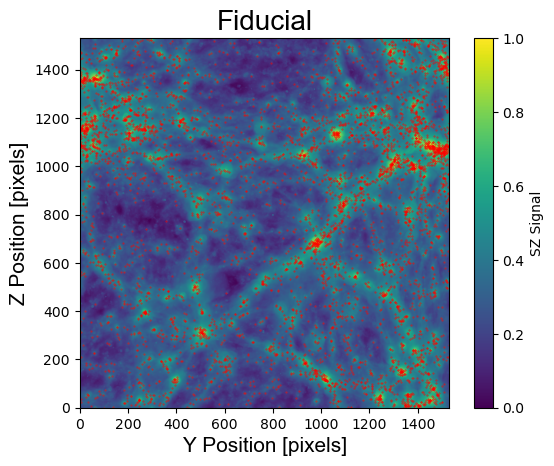

In [11]:
savea='EAGLE/snap_z1/galaxy_catalog.hdf5'
sim_name = 'RefL0050N0752'
snapshot = 19
make_gal_hdf5_eagle(sim_name, snapshot,savea,1)

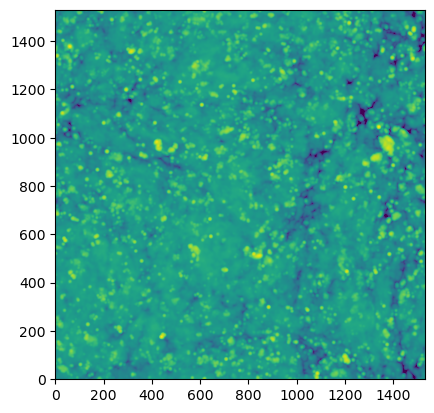

In [28]:
eagle = np.load('/Volumes/easystore/RAFIKI_CGM_mock_library/EAGLE/snap_z1/tSZ/EAGLE_1_x_szy.npy') 
plt.imshow(eagle,norm=colors.LogNorm(vmin=eagle.min(), vmax=eagle.max()), origin='lower')

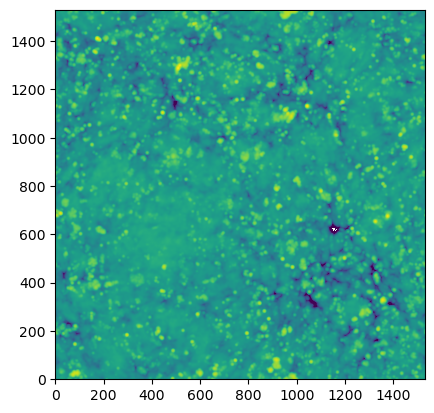

In [29]:
eagle = np.load('/Volumes/easystore/RAFIKI_CGM_mock_library/EAGLE/snap_z1/tSZ/EAGLE_1_y_szy.npy') 
plt.imshow(eagle,norm=colors.LogNorm(vmin=eagle.min(), vmax=eagle.max()), origin='lower')

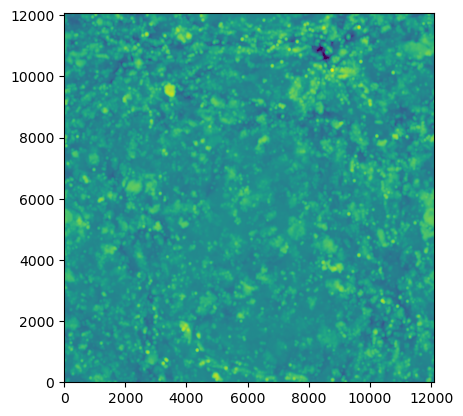

In [31]:
eagle = np.load('/Volumes/easystore/RAFIKI_CGM_mock_library/EAGLE/snap_z0_1/tSZ/EAGLE_0_1_z_szy.npy') 
plt.imshow(eagle,norm=colors.LogNorm(vmin=eagle.min(), vmax=eagle.max()), origin='lower')